# External Baseline Benchmark — Phase 1 v4

This section configures and evaluates the neural forecasting backbones used by the downstream transfer and intervention experiments.


In [1]:

from pathlib import Path
from types import SimpleNamespace
import copy
import gc
import importlib
import inspect
import math
import os
import random
import re
import sys
import time
import traceback
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore")

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    free_b, total_b = (
        torch.cuda.mem_get_info()
    )

    print(
        f"CUDA memory: "
        f"{free_b/1024**3:.1f} / "
        f"{total_b/1024**3:.1f} GiB free"
    )


Python: 3.8.10 (default, Mar 15 2022, 12:22:08) 
[GCC 9.4.0]
PyTorch: 2.4.1+cu121
Device: cuda
GPU: NVIDIA A100-SXM4-80GB
CUDA memory: 69.7 / 79.2 GiB free


## 1. Configuration

In [2]:

SEED = 2026

SEQ_LEN = 96
LABEL_LEN = 48

HORIZONS = [
    96,
    192,
    336,
    720,
]

BASELINES = [
    "DLinear",
    "PatchTST",
    "TimesNet",
    "iTransformer",
]

TRAIN_EPOCHS = 30
PATIENCE = 6
NUM_WORKERS = 2

RESUME = True

# For a very short pipeline test, set e.g. 2.
# Use None for the actual benchmark.
MAX_RUNS = None

OUTPUT_DIR = Path(
    "./results_external_baselines_phase1_direct"
)

CHECKPOINT_DIR = (
    OUTPUT_DIR
    /
    "checkpoints"
)

LOG_DIR = (
    OUTPUT_DIR
    /
    "logs"
)

for p in [
    OUTPUT_DIR,
    CHECKPOINT_DIR,
    LOG_DIR,
]:

    p.mkdir(
        parents=True,
        exist_ok=True,
    )


def set_seed(
    seed
):
    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )


set_seed(
    SEED
)

if torch.cuda.is_available():

    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True


## 2. Locate Time-Series-Library source

In [3]:

MANUAL_TSL_ROOT = None

TSLIB_CANDIDATES = [
    Path(
        "/data/Time-Series-Library_v2"
    ),
    Path(
        "/data/Time-Series-Library"
    ),
    Path(
        "/data/time-series-foundation-model/"
        "Time-Series-Library"
    ),
    Path(
        "/data/time-series_foundation_model/"
        "Time-Series-Library"
    ),
    Path.cwd()
    /
    "Time-Series-Library_v2",
    Path.cwd()
    /
    "Time-Series-Library",
]


def is_tslib_root(
    p
):
    p = Path(
        p
    )

    return (
        p.is_dir()
        and
        (
            p
            /
            "data_provider"
            /
            "data_factory.py"
        ).exists()
        and
        (
            p
            /
            "models"
        ).is_dir()
        and
        (
            p
            /
            "layers"
        ).is_dir()
    )


candidate_roots = []

if MANUAL_TSL_ROOT is not None:

    candidate_roots.append(
        Path(
            MANUAL_TSL_ROOT
        )
    )

candidate_roots.extend(
    TSLIB_CANDIDATES
)

for base in [
    Path("/data"),
    Path("/workspace"),
    Path("/root"),
    Path("/home"),
]:

    if not base.exists():
        continue

    try:

        for p in base.glob(
            "**/Time-Series-Library*"
        ):

            if p.is_dir():
                candidate_roots.append(
                    p
                )

    except (
        OSError,
        PermissionError,
    ):
        pass


TSL_ROOT = next(
    (
        p.resolve()
        for p in candidate_roots
        if is_tslib_root(
            p
        )
    ),
    None,
)

if TSL_ROOT is None:

    raise FileNotFoundError(
        "Could not locate a TSLib source tree containing "
        "data_provider/, models/, and layers/. "
        "Set MANUAL_TSL_ROOT manually."
    )


print(
    "TSLib source:",
    TSL_ROOT
)

if str(
    TSL_ROOT
) not in sys.path:

    sys.path.insert(
        0,
        str(
            TSL_ROOT
        ),
    )


TSLib source: /data/Time-Series-Library


## 3. Model-only direct-import pre-flight

This section configures and evaluates the neural forecasting backbones used by the downstream transfer and intervention experiments.


In [4]:

# Important:
# Do NOT import:
#   - exp.exp_basic
#   - data_provider.data_factory
#   - data_provider.data_loader
#
# The stock TSLib data_loader eagerly imports M4 / UEA utilities,
# which introduces unrelated optional dependencies such as
# patoolib and sktime. We use the exact same local data pipeline
# as the Hybrid-0 experiments instead.

MODEL_MODULES = {}
import_failures = {}

for model_name in BASELINES:

    try:

        module = importlib.import_module(
            f"models.{model_name}"
        )

        MODEL_MODULES[
            model_name
        ] = module

        print(
            f"{model_name:12s}: OK"
        )

    except Exception:

        import_failures[
            model_name
        ] = (
            traceback.format_exc()
        )

        print(
            f"{model_name:12s}: FAILED"
        )

        print(
            traceback.format_exc()[
                -2500:
            ]
        )


if import_failures:

    raise RuntimeError(
        "One or more CORE model modules could not be imported. "
        "The traceback above identifies the specific model dependency."
    )


print(
    "\nAll four core model modules imported successfully."
)


DLinear     : OK
PatchTST    : OK
TimesNet    : OK
iTransformer: OK

All four core model modules imported successfully.


## 4. Dataset discovery

In [5]:

DATASET_CANDIDATES = {
    "Electricity": [
        Path(
            "/data/dataset/electricity/electricity.csv"
        ),
        Path(
            "/data/dataset/ECL/electricity.csv"
        ),
        Path(
            "/data/dataset/electricity.csv"
        ),
    ],

    "Weather": [
        Path(
            "/data/dataset/weather/weather.csv"
        ),
        Path(
            "/data/dataset/weather.csv"
        ),
    ],

    "Solar": [
        Path(
            "/data/dataset/solar/solar_AL.txt"
        ),
        Path(
            "/data/dataset/Solar/solar_AL.txt"
        ),
        Path(
            "/data/dataset/solar_AL.txt"
        ),
    ],

    "ETTh1": [
        Path(
            "/data/dataset/ETT-small/ETTh1.csv"
        ),
        Path(
            "/data/dataset/ETTh1.csv"
        ),
    ],

    "ETTm1": [
        Path(
            "/data/dataset/ETT-small/ETTm1.csv"
        ),
        Path(
            "/data/dataset/ETTm1.csv"
        ),
    ],
}


DATASET_FILES = {}

for dataset_name, candidates in (
    DATASET_CANDIDATES.items()
):

    found = next(
        (
            p.resolve()
            for p in candidates
            if p.exists()
        ),
        None,
    )

    if found is None:

        raise FileNotFoundError(
            f"{dataset_name}: "
            f"dataset file not found. "
            f"Checked: {candidates}"
        )

    DATASET_FILES[
        dataset_name
    ] = found


for k, v in DATASET_FILES.items():

    print(
        f"{k:12s}",
        "->",
        v
    )


Electricity  -> /data/dataset/electricity/electricity.csv
Weather      -> /data/dataset/weather/weather.csv
Solar        -> /data/dataset/solar/solar_AL.txt
ETTh1        -> /data/dataset/ETT-small/ETTh1.csv
ETTm1        -> /data/dataset/ETT-small/ETTm1.csv


## 5. Dataset metadata

In [6]:

DATASET_SPECS = {
    "Electricity": {
        "data":
            "custom",
        "channels":
            321,
        "freq":
            "h",
        "target":
            "OT",
    },

    "Weather": {
        "data":
            "custom",
        "channels":
            21,
        "freq":
            "t",
        "target":
            "OT",
    },

    "Solar": {
        "data":
            "Solar",
        "channels":
            137,
        "freq":
            "h",
        "target":
            "OT",
    },

    "ETTh1": {
        "data":
            "ETTh1",
        "channels":
            7,
        "freq":
            "h",
        "target":
            "OT",
    },

    "ETTm1": {
        "data":
            "ETTm1",
        "channels":
            7,
        "freq":
            "t",
        "target":
            "OT",
    },
}


## 6. Fixed model configurations

In [7]:

MODEL_CONFIGS = {
    "DLinear": {
        "learning_rate":
            0.005,
        "batch_size":
            32,
        "individual":
            False,
        "moving_avg":
            25,
    },

    "PatchTST": {
        "learning_rate":
            0.0001,
        "batch_size":
            32,
        "e_layers":
            3,
        "n_heads":
            16,
        "d_model":
            128,
        "d_ff":
            256,
        "dropout":
            0.2,
        "fc_dropout":
            0.2,
        "head_dropout":
            0.0,
        "patch_len":
            16,
        "stride":
            8,
        "padding_patch":
            "end",
        "revin":
            1,
        "affine":
            0,
        "subtract_last":
            0,
        "decomposition":
            0,
        "kernel_size":
            25,
        "individual":
            0,
    },

    "TimesNet": {
        "learning_rate":
            0.0001,
        "batch_size":
            32,
        "e_layers":
            2,
        "d_layers":
            1,
        "d_model":
            32,
        "d_ff":
            64,
        "n_heads":
            8,
        "top_k":
            5,
        "num_kernels":
            6,
        "factor":
            3,
        "dropout":
            0.1,
    },

    "iTransformer": {
        "learning_rate":
            0.0001,
        "batch_size":
            32,
        "e_layers":
            3,
        "d_layers":
            1,
        "n_heads":
            8,
        "d_model":
            512,
        "d_ff":
            512,
        "factor":
            3,
        "dropout":
            0.1,
        "class_strategy":
            "projection",
        "use_norm":
            1,
    },
}


def choose_batch_size(
    model_name,
    dataset_name,
    H,
):
    batch = int(
        MODEL_CONFIGS[
            model_name
        ][
            "batch_size"
        ]
    )

    if dataset_name == "Electricity":

        batch = min(
            batch,
            16,
        )

        if (
            model_name
            ==
            "iTransformer"
            and
            H >= 336
        ):

            batch = min(
                batch,
                8,
            )

    if dataset_name == "Solar":

        batch = min(
            batch,
            16,
        )

    return batch


## 7. Build TSLib-compatible args

In [8]:

def build_args(
    model_name,
    dataset_name,
    H,
):
    spec = (
        DATASET_SPECS[
            dataset_name
        ]
    )

    data_file = (
        DATASET_FILES[
            dataset_name
        ]
    )

    cfg = dict(
        MODEL_CONFIGS[
            model_name
        ]
    )

    args = SimpleNamespace(
        # task
        task_name=
            "long_term_forecast",
        model=
            model_name,

        # data
        data=
            spec[
                "data"
            ],
        root_path=
            str(
                data_file.parent
            )
            +
            "/",
        data_path=
            data_file.name,
        features=
            "M",
        target=
            spec[
                "target"
            ],
        freq=
            spec[
                "freq"
            ],
        checkpoints=
            str(
                CHECKPOINT_DIR
            ),

        # forecasting
        seq_len=
            SEQ_LEN,
        label_len=
            LABEL_LEN,
        pred_len=
            H,
        seasonal_patterns=
            "Monthly",
        inverse=
            False,

        # dimensions
        enc_in=
            spec[
                "channels"
            ],
        dec_in=
            spec[
                "channels"
            ],
        c_out=
            spec[
                "channels"
            ],

        # common architecture defaults
        e_layers=
            cfg.get(
                "e_layers",
                2,
            ),
        d_layers=
            cfg.get(
                "d_layers",
                1,
            ),
        factor=
            cfg.get(
                "factor",
                3,
            ),
        d_model=
            cfg.get(
                "d_model",
                128,
            ),
        n_heads=
            cfg.get(
                "n_heads",
                8,
            ),
        d_ff=
            cfg.get(
                "d_ff",
                256,
            ),
        moving_avg=
            cfg.get(
                "moving_avg",
                25,
            ),
        distil=
            True,
        dropout=
            cfg.get(
                "dropout",
                0.1,
            ),
        embed=
            "timeF",
        activation=
            "gelu",
        output_attention=
            False,

        # TimesNet
        top_k=
            cfg.get(
                "top_k",
                5,
            ),
        num_kernels=
            cfg.get(
                "num_kernels",
                6,
            ),

        # PatchTST
        fc_dropout=
            cfg.get(
                "fc_dropout",
                0.0,
            ),
        head_dropout=
            cfg.get(
                "head_dropout",
                0.0,
            ),
        patch_len=
            cfg.get(
                "patch_len",
                16,
            ),
        stride=
            cfg.get(
                "stride",
                8,
            ),
        padding_patch=
            cfg.get(
                "padding_patch",
                "end",
            ),
        revin=
            cfg.get(
                "revin",
                1,
            ),
        affine=
            cfg.get(
                "affine",
                0,
            ),
        subtract_last=
            cfg.get(
                "subtract_last",
                0,
            ),
        decomposition=
            cfg.get(
                "decomposition",
                0,
            ),
        kernel_size=
            cfg.get(
                "kernel_size",
                25,
            ),
        individual=
            cfg.get(
                "individual",
                False,
            ),

        # iTransformer
        class_strategy=
            cfg.get(
                "class_strategy",
                "projection",
            ),
        use_norm=
            cfg.get(
                "use_norm",
                1,
            ),

        # loader/training
        batch_size=
            choose_batch_size(
                model_name,
                dataset_name,
                H,
            ),
        num_workers=
            NUM_WORKERS,
        learning_rate=
            float(
                cfg[
                    "learning_rate"
                ]
            ),

        # fields used by some TSLib forks
        augmentation_ratio=
            0,
        seed=
            SEED,
        use_gpu=
            torch.cuda.is_available(),
        gpu=
            0,
        use_multi_gpu=
            False,
        devices=
            "0",
        channel_independence=
            0,
    )

    return args


## 8. Dependency-free dataset pipeline

This section configures and evaluates the neural forecasting backbones used by the downstream transfer and intervention experiments.


In [9]:

from torch.utils.data import Dataset, DataLoader


def load_numeric_series(
    dataset_name,
    path,
):
    path = Path(
        path
    )

    if path.suffix.lower() == ".csv":

        df = pd.read_csv(
            path
        )

        # Drop the timestamp/date column when present.
        date_col = None

        for candidate in [
            "date",
            "datetime",
            "timestamp",
            "time",
        ]:

            if candidate in df.columns:
                date_col = candidate
                break

        if date_col is None:

            first_col = df.columns[
                0
            ]

            if not pd.api.types.is_numeric_dtype(
                df[
                    first_col
                ]
            ):

                date_col = (
                    first_col
                )

        if date_col is not None:

            df = df.drop(
                columns=[
                    date_col
                ]
            )

        df = df.select_dtypes(
            include=[
                np.number
            ]
        )

        x = df.to_numpy(
            dtype=
                np.float32
        )

    else:

        # Solar is normally comma-separated text.
        try:

            x = np.loadtxt(
                path,
                delimiter=",",
                dtype=
                    np.float32,
            )

        except Exception:

            x = np.loadtxt(
                path,
                dtype=
                    np.float32,
            )

        if x.ndim == 1:

            x = x[
                :,
                None
            ]

    if x.ndim != 2:

        raise ValueError(
            f"{dataset_name}: "
            f"unexpected shape "
            f"{x.shape}"
        )

    if not np.isfinite(
        x
    ).all():

        raise ValueError(
            f"{dataset_name}: "
            "non-finite values"
        )

    return x


def split_boundaries(
    dataset_name,
    T,
):
    if dataset_name == "ETTh1":

        train_end = (
            12
            *
            30
            *
            24
        )

        val_end = (
            train_end
            +
            4
            *
            30
            *
            24
        )

        test_end = (
            val_end
            +
            4
            *
            30
            *
            24
        )

        return (
            min(
                train_end,
                T
            ),
            min(
                val_end,
                T
            ),
            min(
                test_end,
                T
            ),
        )

    if dataset_name == "ETTm1":

        unit = (
            30
            *
            24
            *
            4
        )

        train_end = (
            12
            *
            unit
        )

        val_end = (
            train_end
            +
            4
            *
            unit
        )

        test_end = (
            val_end
            +
            4
            *
            unit
        )

        return (
            min(
                train_end,
                T
            ),
            min(
                val_end,
                T
            ),
            min(
                test_end,
                T
            ),
        )

    train_end = int(
        0.70
        *
        T
    )

    val_end = int(
        0.80
        *
        T
    )

    return (
        train_end,
        val_end,
        T,
    )


def load_and_normalize(
    dataset_name,
):
    raw = load_numeric_series(
        dataset_name,
        DATASET_FILES[
            dataset_name
        ],
    )

    T, C = raw.shape

    (
        train_end,
        val_end,
        test_end,
    ) = split_boundaries(
        dataset_name,
        T,
    )

    train_slice = raw[
        :train_end
    ]

    mean = train_slice.mean(
        axis=0,
        keepdims=True,
    )

    std = train_slice.std(
        axis=0,
        keepdims=True,
    )

    std = np.maximum(
        std,
        1e-6,
    )

    x = (
        raw
        -
        mean
    ) / std

    return (
        x.astype(
            np.float32
        ),
        {
            "T":
                T,
            "C":
                C,
            "train_end":
                train_end,
            "val_end":
                val_end,
            "test_end":
                test_end,
        },
    )


class BaselineForecastDataset(Dataset):

    def __init__(
        self,
        data,
        seq_len,
        label_len,
        pred_len,
        target_start_min,
        target_end_exclusive,
    ):
        self.data = torch.from_numpy(
            data
        ).float()

        self.seq_len = int(
            seq_len
        )

        self.label_len = int(
            label_len
        )

        self.pred_len = int(
            pred_len
        )

        # Forecast origin t:
        # x = [t-seq_len, ..., t-1]
        # y decoder/target = [t-label_len, ..., t+pred_len-1]
        first_t = max(
            self.seq_len,
            self.label_len,
            int(
                target_start_min
            ),
        )

        last_t = (
            int(
                target_end_exclusive
            )
            -
            self.pred_len
        )

        self.origins = np.arange(
            first_t,
            last_t + 1,
            dtype=
                np.int64,
        )

        if len(
            self.origins
        ) == 0:

            raise ValueError(
                "No valid forecasting windows."
            )

    def __len__(
        self
    ):
        return len(
            self.origins
        )

    def __getitem__(
        self,
        idx,
    ):
        t = int(
            self.origins[
                idx
            ]
        )

        x = self.data[
            t-self.seq_len:
            t
        ]

        y = self.data[
            t-self.label_len:
            t+self.pred_len
        ]

        return (
            x,
            y,
        )


def prepare_datasets(
    dataset_name,
    H,
):
    x, meta = (
        load_and_normalize(
            dataset_name
        )
    )

    expected_C = (
        DATASET_SPECS[
            dataset_name
        ][
            "channels"
        ]
    )

    if meta[
        "C"
    ] != expected_C:

        raise ValueError(
            f"{dataset_name}: "
            f"detected C={meta['C']} "
            f"but config expects "
            f"C={expected_C}"
        )

    train_ds = (
        BaselineForecastDataset(
            x,
            SEQ_LEN,
            LABEL_LEN,
            H,
            target_start_min=
                SEQ_LEN,
            target_end_exclusive=
                meta[
                    "train_end"
                ],
        )
    )

    val_ds = (
        BaselineForecastDataset(
            x,
            SEQ_LEN,
            LABEL_LEN,
            H,
            target_start_min=
                meta[
                    "train_end"
                ],
            target_end_exclusive=
                meta[
                    "val_end"
                ],
        )
    )

    test_ds = (
        BaselineForecastDataset(
            x,
            SEQ_LEN,
            LABEL_LEN,
            H,
            target_start_min=
                meta[
                    "val_end"
                ],
            target_end_exclusive=
                meta[
                    "test_end"
                ],
        )
    )

    return (
        x,
        train_ds,
        val_ds,
        test_ds,
        meta,
    )


def make_loaders(
    train_ds,
    val_ds,
    test_ds,
    batch_size,
    seed,
):
    g = torch.Generator()

    g.manual_seed(
        seed
        +
        100000
    )

    common = dict(
        num_workers=
            NUM_WORKERS,
        pin_memory=
            torch.cuda.is_available(),
        drop_last=
            False,
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=
            batch_size,
        shuffle=
            True,
        generator=
            g,
        **common,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=
            batch_size,
        shuffle=
            False,
        **common,
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=
            batch_size,
        shuffle=
            False,
        **common,
    )

    return (
        train_loader,
        val_loader,
        test_loader,
    )


# Pre-flight with ETTh1 H96.
(
    x_pf,
    train_set_pf,
    val_set_pf,
    test_set_pf,
    meta_pf,
) = prepare_datasets(
    "ETTh1",
    96,
)

(
    train_loader_pf,
    val_loader_pf,
    test_loader_pf,
) = make_loaders(
    train_set_pf,
    val_set_pf,
    test_set_pf,
    batch_size=
        32,
    seed=
        SEED,
)

batch_pf = next(
    iter(
        train_loader_pf
    )
)

print(
    "Detected metadata:",
    meta_pf
)

print(
    "Train / Val / Test:",
    len(
        train_set_pf
    ),
    len(
        val_set_pf
    ),
    len(
        test_set_pf
    ),
)

print(
    "Batch fields:",
    len(
        batch_pf
    ),
)

print(
    "x:",
    tuple(
        batch_pf[
            0
        ].shape
    )
)

print(
    "y:",
    tuple(
        batch_pf[
            1
        ].shape
    )
)

assert (
    batch_pf[
        0
    ].shape[
        1
    ]
    ==
    SEQ_LEN
)

assert (
    batch_pf[
        1
    ].shape[
        1
    ]
    ==
    LABEL_LEN
    +
    96
)

del (
    x_pf,
    train_set_pf,
    val_set_pf,
    test_set_pf,
    train_loader_pf,
    val_loader_pf,
    test_loader_pf,
    batch_pf,
)

gc.collect()


Detected metadata: {'T': 17420, 'C': 7, 'train_end': 8640, 'val_end': 11520, 'test_end': 14400}
Train / Val / Test: 8449 2785 2785
Batch fields: 2
x: (32, 96, 7)
y: (32, 144, 7)


0

## 9. Model-construction pre-flight

In [10]:

def build_model(
    model_name,
    args,
):
    module = (
        MODEL_MODULES[
            model_name
        ]
    )

    model = (
        module
        .Model(
            args
        )
        .float()
        .to(
            DEVICE
        )
    )

    return model


model_preflight_rows = []

for model_name in BASELINES:

    print(
        "\n",
        "="
        *
        80
    )

    print(
        model_name
    )

    try:

        args_pf = build_args(
            model_name,
            "ETTh1",
            96,
        )

        model_pf = build_model(
            model_name,
            args_pf,
        )

        n_params = sum(
            p.numel()
            for p in model_pf.parameters()
        )

        model_preflight_rows.append({
            "model":
                model_name,
            "parameters":
                n_params,
            "status":
                "OK",
        })

        print(
            "Parameters:",
            f"{n_params:,}"
        )

        del model_pf

        gc.collect()

        if DEVICE.type == "cuda":

            torch.cuda.empty_cache()

    except Exception:

        model_preflight_rows.append({
            "model":
                model_name,
            "parameters":
                np.nan,
            "status":
                "FAILED",
        })

        print(
            traceback.format_exc()
        )


model_preflight_df = pd.DataFrame(
    model_preflight_rows
)

display(
    model_preflight_df
)

if (
    model_preflight_df[
        "status"
    ]
    !=
    "OK"
).any():

    raise RuntimeError(
        "At least one baseline model could not be constructed. "
        "The traceback above identifies the incompatible config field."
    )



DLinear
Parameters: 18,624

PatchTST
Parameters: 547,296

TimesNet
Parameters: 2,363,783

iTransformer
Parameters: 4,833,888


,model,parameters,status
0,DLinear,18624,OK
1,PatchTST,547296,OK
2,TimesNet,2363783,OK
3,iTransformer,4833888,OK


## 10. Generic forecasting forward pass

In [11]:

def unpack_batch(
    batch
):
    if len(
        batch
    ) != 2:

        raise RuntimeError(
            f"Expected (x, y), got "
            f"{len(batch)} fields."
        )

    (
        batch_x,
        batch_y,
    ) = batch

    return (
        batch_x.float().to(
            DEVICE,
            non_blocking=True,
        ),
        batch_y.float().to(
            DEVICE,
            non_blocking=True,
        ),
    )


def forward_forecast(
    model,
    batch,
    args,
):
    (
        batch_x,
        batch_y,
    ) = unpack_batch(
        batch
    )

    dec_zeros = torch.zeros_like(
        batch_y[
            :,
            -args.pred_len:,
            :
        ]
    )

    dec_inp = torch.cat(
        [
            batch_y[
                :,
                :args.label_len,
                :
            ],
            dec_zeros,
        ],
        dim=1,
    )

    # No calendar covariates are supplied.
    # This matches the Hybrid-0 setting, which also uses raw series only.
    outputs = model(
        batch_x,
        None,
        dec_inp,
        None,
    )

    if isinstance(
        outputs,
        tuple,
    ):

        outputs = outputs[
            0
        ]

    outputs = outputs[
        :,
        -args.pred_len:,
        :
    ]

    target = batch_y[
        :,
        -args.pred_len:,
        :
    ]

    return (
        outputs,
        target,
    )


## 11. One-forward sanity check for every baseline

In [12]:

for model_name in BASELINES:

    print(
        "\n",
        model_name
    )

    args_pf = build_args(
        model_name,
        "ETTh1",
        96,
    )

    (
        x_pf,
        train_set_pf,
        val_set_pf,
        test_set_pf,
        meta_pf,
    ) = prepare_datasets(
        "ETTh1",
        96,
    )

    (
        train_loader_pf,
        val_loader_pf,
        test_loader_pf,
    ) = make_loaders(
        train_set_pf,
        val_set_pf,
        test_set_pf,
        batch_size=
            args_pf.batch_size,
        seed=
            SEED,
    )

    batch_pf = next(
        iter(
            train_loader_pf
        )
    )

    model_pf = build_model(
        model_name,
        args_pf,
    )

    model_pf.eval()

    with torch.no_grad():

        pred_pf, y_pf = (
            forward_forecast(
                model_pf,
                batch_pf,
                args_pf,
            )
        )

    print(
        "pred:",
        tuple(
            pred_pf.shape
        ),
        "| target:",
        tuple(
            y_pf.shape
        ),
        "| finite:",
        bool(
            torch.isfinite(
                pred_pf
            ).all()
        ),
    )

    assert (
        pred_pf.shape
        ==
        y_pf.shape
    )

    assert torch.isfinite(
        pred_pf
    ).all()

    del (
        x_pf,
        train_set_pf,
        val_set_pf,
        test_set_pf,
        train_loader_pf,
        val_loader_pf,
        test_loader_pf,
        batch_pf,
        model_pf,
        pred_pf,
        y_pf,
    )

    gc.collect()

    if DEVICE.type == "cuda":

        torch.cuda.empty_cache()



 DLinear
pred: (32, 96, 7) | target: (32, 96, 7) | finite: True

 PatchTST
pred: (32, 96, 7) | target: (32, 96, 7) | finite: True

 TimesNet
pred: (32, 96, 7) | target: (32, 96, 7) | finite: True

 iTransformer
pred: (32, 96, 7) | target: (32, 96, 7) | finite: True


## 12. Evaluation

In [13]:

@torch.no_grad()
def evaluate_model(
    model,
    loader,
    args,
):
    model.eval()

    total_sse = 0.0
    total_sae = 0.0
    total_n = 0

    for batch in loader:

        pred, target = (
            forward_forecast(
                model,
                batch,
                args,
            )
        )

        err = (
            pred
            -
            target
        )

        total_sse += (
            err.square()
            .sum()
            .item()
        )

        total_sae += (
            err.abs()
            .sum()
            .item()
        )

        total_n += (
            err.numel()
        )

    return (
        total_sse
        /
        total_n,
        total_sae
        /
        total_n,
    )


## 13. Fixed learning-rate scheduling

In [14]:

def adjust_lr(
    optimizer,
    epoch,
    model_name,
    base_lr,
):
    # Fixed before looking at results.
    #
    # PatchTST: slow decay.
    # Other baselines: conservative step decay rather than
    # TSLib type1's very aggressive epoch-wise halving.
    if model_name == "PatchTST":

        if epoch < 3:

            lr = (
                base_lr
            )

        else:

            lr = (
                base_lr
                *
                (
                    0.9
                    **
                    (
                        epoch
                        -
                        2
                    )
                )
            )

    else:

        lr = (
            base_lr
            *
            (
                0.5
                **
                (
                    (
                        epoch
                        -
                        1
                    )
                    //
                    5
                )
            )
        )

    for group in (
        optimizer
        .param_groups
    ):

        group[
            "lr"
        ] = lr

    return lr


## 14. Checkpoint / resume utilities

In [15]:

def condition_dir(
    model_name,
    dataset_name,
    H,
):
    path = (
        OUTPUT_DIR
        /
        model_name
        /
        dataset_name
        /
        f"H{H}"
    )

    path.mkdir(
        parents=True,
        exist_ok=True,
    )

    return path


def result_path(
    model_name,
    dataset_name,
    H,
):
    return (
        condition_dir(
            model_name,
            dataset_name,
            H,
        )
        /
        "result.csv"
    )


def ckpt_path(
    model_name,
    dataset_name,
    H,
):
    return (
        condition_dir(
            model_name,
            dataset_name,
            H,
        )
        /
        "best_model.pt"
    )


def load_completed_result(
    model_name,
    dataset_name,
    H,
):
    path = result_path(
        model_name,
        dataset_name,
        H,
    )

    if not path.exists():
        return None

    try:

        df = pd.read_csv(
            path
        )

        if len(
            df
        ) != 1:

            return None

        row = df.iloc[
            0
        ].to_dict()

        if not (
            np.isfinite(
                row[
                    "test_mse"
                ]
            )
            and
            np.isfinite(
                row[
                    "test_mae"
                ]
            )
        ):

            return None

        return row

    except Exception:

        return None


## 15. Train one baseline condition

In [16]:

def train_one_condition(
    model_name,
    dataset_name,
    H,
):
    if RESUME:

        completed = (
            load_completed_result(
                model_name,
                dataset_name,
                H,
            )
        )

        if completed is not None:

            print(
                "Reusing:",
                model_name,
                dataset_name,
                H,
            )

            return completed

    set_seed(
        SEED
    )

    args = build_args(
        model_name,
        dataset_name,
        H,
    )

    (
        x_norm,
        train_set,
        val_set,
        test_set,
        meta,
    ) = prepare_datasets(
        dataset_name,
        H,
    )

    (
        train_loader,
        val_loader,
        test_loader,
    ) = make_loaders(
        train_set,
        val_set,
        test_set,
        batch_size=
            args.batch_size,
        seed=
            SEED,
    )

    model = build_model(
        model_name,
        args,
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=
            args.learning_rate,
    )

    best_val = float(
        "inf"
    )

    best_epoch = -1

    best_state = None

    bad_epochs = 0

    history = []

    start_time = time.time()

    for epoch in range(
        1,
        TRAIN_EPOCHS + 1,
    ):

        lr = adjust_lr(
            optimizer,
            epoch,
            model_name,
            args.learning_rate,
        )

        model.train()

        train_sse = 0.0
        train_n = 0

        for batch in train_loader:

            optimizer.zero_grad(
                set_to_none=True
            )

            pred, target = (
                forward_forecast(
                    model,
                    batch,
                    args,
                )
            )

            loss = F.mse_loss(
                pred,
                target,
            )

            if not torch.isfinite(
                loss
            ):

                raise FloatingPointError(
                    f"Non-finite loss: "
                    f"{model_name}, "
                    f"{dataset_name}, "
                    f"H={H}"
                )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0,
            )

            optimizer.step()

            train_sse += (
                (
                    pred.detach()
                    -
                    target
                )
                .square()
                .sum()
                .item()
            )

            train_n += (
                target.numel()
            )

        train_mse = (
            train_sse
            /
            train_n
        )

        val_mse, val_mae = (
            evaluate_model(
                model,
                val_loader,
                args,
            )
        )

        history.append({
            "epoch":
                epoch,
            "learning_rate":
                lr,
            "train_mse":
                train_mse,
            "val_mse":
                val_mse,
            "val_mae":
                val_mae,
        })

        print(
            f"{model_name:12s} | "
            f"{dataset_name:11s} | "
            f"H={H:3d} | "
            f"epoch={epoch:02d} | "
            f"train={train_mse:.6f} | "
            f"val={val_mse:.6f} | "
            f"lr={lr:.2e}"
        )

        if val_mse < best_val:

            best_val = (
                val_mse
            )

            best_epoch = (
                epoch
            )

            best_state = {
                k:
                    v.detach()
                    .cpu()
                    .clone()
                for k, v
                in model
                .state_dict()
                .items()
            }

            bad_epochs = 0

        else:

            bad_epochs += 1

            if bad_epochs >= (
                PATIENCE
            ):

                print(
                    "Early stopping."
                )

                break

    if best_state is None:

        raise RuntimeError(
            "No best checkpoint."
        )

    model.load_state_dict(
        best_state
    )

    torch.save(
        best_state,
        ckpt_path(
            model_name,
            dataset_name,
            H,
        ),
    )

    test_mse, test_mae = (
        evaluate_model(
            model,
            test_loader,
            args,
        )
    )

    runtime_sec = (
        time.time()
        -
        start_time
    )

    n_params = sum(
        p.numel()
        for p in model.parameters()
    )

    result = {
        "model":
            model_name,
        "dataset":
            dataset_name,
        "pred_len":
            H,
        "seed":
            SEED,
        "seq_len":
            SEQ_LEN,
        "label_len":
            LABEL_LEN,
        "batch_size":
            args.batch_size,
        "best_epoch":
            best_epoch,
        "best_val_mse":
            best_val,
        "test_mse":
            test_mse,
        "test_mae":
            test_mae,
        "parameters":
            n_params,
        "runtime_sec":
            runtime_sec,
        "train_samples":
            len(
                train_set
            ),
        "val_samples":
            len(
                val_set
            ),
        "test_samples":
            len(
                test_set
            ),
    }

    pd.DataFrame(
        [
            result
        ]
    ).to_csv(
        result_path(
            model_name,
            dataset_name,
            H,
        ),
        index=False,
    )

    pd.DataFrame(
        history
    ).to_csv(
        condition_dir(
            model_name,
            dataset_name,
            H,
        )
        /
        "history.csv",
        index=False,
    )

    print(
        "TEST:",
        f"MSE={test_mse:.6f}",
        f"MAE={test_mae:.6f}",
        f"best_epoch={best_epoch}",
    )

    del (
        model,
        optimizer,
        train_set,
        train_loader,
        val_set,
        val_loader,
        test_set,
        test_loader,
        x_norm,
    )

    gc.collect()

    if DEVICE.type == "cuda":

        torch.cuda.empty_cache()

    return result


## 16. Run all 80 core-baseline conditions

This section configures and evaluates the neural forecasting backbones used by the downstream transfer and intervention experiments.


In [ ]:

planned_runs = [
    (
        model_name,
        dataset_name,
        H,
    )
    for model_name in BASELINES
    for dataset_name in DATASET_SPECS
    for H in HORIZONS
]

if MAX_RUNS is not None:

    planned_runs = (
        planned_runs[
            :MAX_RUNS
        ]
    )


all_results = []

failures = []

print(
    "Planned runs:",
    len(
        planned_runs
    )
)


for run_idx, (
    model_name,
    dataset_name,
    H,
) in enumerate(
    planned_runs,
    start=1,
):

    print(
        "\n"
        +
        "="
        *
        110
    )

    print(
        f"[{run_idx}/{len(planned_runs)}] "
        f"{model_name} | "
        f"{dataset_name} | "
        f"H={H}"
    )

    print(
        "="
        *
        110
    )

    try:

        result = (
            train_one_condition(
                model_name,
                dataset_name,
                H,
            )
        )

        all_results.append(
            result
        )

    except RuntimeError as exc:

        # One automatic OOM retry with half batch size.
        if (
            "out of memory"
            in
            str(
                exc
            ).lower()
            and
            torch.cuda.is_available()
        ):

            print(
                "CUDA OOM. "
                "This condition needs a smaller batch size."
            )

            if DEVICE.type == "cuda":

                torch.cuda.empty_cache()

        failures.append({
            "model":
                model_name,
            "dataset":
                dataset_name,
            "pred_len":
                H,
            "error":
                traceback.format_exc(),
        })

        print(
            traceback.format_exc()[
                -4000:
            ]
        )

    except Exception:

        failures.append({
            "model":
                model_name,
            "dataset":
                dataset_name,
            "pred_len":
                H,
            "error":
                traceback.format_exc(),
        })

        print(
            traceback.format_exc()[
                -4000:
            ]
        )

    pd.DataFrame(
        all_results
    ).to_csv(
        OUTPUT_DIR
        /
        "baseline_results_partial.csv",
        index=False,
    )

    if failures:

        pd.DataFrame(
            failures
        ).to_csv(
            OUTPUT_DIR
            /
            "baseline_failures.csv",
            index=False,
        )


baseline_df = pd.DataFrame(
    all_results
)

baseline_df.to_csv(
    OUTPUT_DIR
    /
    "baseline_results_phase1_direct.csv",
    index=False,
)

print(
    "\nSuccessful:",
    len(
        baseline_df
    ),
    "/",
    len(
        planned_runs
    ),
)

print(
    "Failures:",
    len(
        failures
    ),
)


Planned runs: 80

[1/80] DLinear | Electricity | H=96
DLinear      | Electricity | H= 96 | epoch=01 | train=0.206511 | val=0.181823 | lr=5.00e-03
DLinear      | Electricity | H= 96 | epoch=02 | train=0.202524 | val=0.177700 | lr=5.00e-03
DLinear      | Electricity | H= 96 | epoch=03 | train=0.202709 | val=0.177674 | lr=5.00e-03
DLinear      | Electricity | H= 96 | epoch=04 | train=0.202916 | val=0.179580 | lr=5.00e-03
DLinear      | Electricity | H= 96 | epoch=05 | train=0.202506 | val=0.181497 | lr=5.00e-03
DLinear      | Electricity | H= 96 | epoch=06 | train=0.198745 | val=0.176484 | lr=2.50e-03
DLinear      | Electricity | H= 96 | epoch=07 | train=0.198833 | val=0.178038 | lr=2.50e-03
DLinear      | Electricity | H= 96 | epoch=08 | train=0.199032 | val=0.178211 | lr=2.50e-03
DLinear      | Electricity | H= 96 | epoch=09 | train=0.198962 | val=0.177804 | lr=2.50e-03
DLinear      | Electricity | H= 96 | epoch=10 | train=0.198964 | val=0.176557 | lr=2.50e-03
DLinear      | Electricity

## 17. Failure report

In [28]:

if failures:

    failure_df = pd.DataFrame(
        failures
    )

    display(
        failure_df[
            [
                "model",
                "dataset",
                "pred_len",
            ]
        ]
    )

    print(
        "\nFirst failure tail:"
    )

    print(
        failure_df.iloc[
            0
        ][
            "error"
        ][
            -5000:
        ]
    )

else:

    print(
        "No baseline failures."
    )


No baseline failures.


## 18. Load final Hybrid-0 results

In [29]:

HYBRID_RESULT_CANDIDATES = [
    Path(
        "./results_final_protocol_hybrid0_H96_H720/"
        "FINAL_20condition_Hybrid0_results.csv"
    ),
    Path(
        "/data/code/2026_08/"
        "results_final_protocol_hybrid0_H96_H720/"
        "FINAL_20condition_Hybrid0_results.csv"
    ),
    Path(
        "/data/results_final_protocol_hybrid0_H96_H720/"
        "FINAL_20condition_Hybrid0_results.csv"
    ),
    Path(
        "/data/Time-Series-Library_v2/"
        "results_final_protocol_hybrid0_H96_H720/"
        "FINAL_20condition_Hybrid0_results.csv"
    ),
]

hybrid_path = next(
    (
        p
        for p in HYBRID_RESULT_CANDIDATES
        if p.exists()
    ),
    None,
)

if hybrid_path is None:

    raise FileNotFoundError(
        "Final Hybrid-0 result CSV not found. "
        "Edit HYBRID_RESULT_CANDIDATES."
    )


print(
    "Hybrid result:",
    hybrid_path
)

hybrid_raw = pd.read_csv(
    hybrid_path
)

hybrid_df = (
    hybrid_raw[
        [
            "dataset",
            "pred_len",
            "test_mse",
            "test_mae",
        ]
    ]
    .rename(
        columns={
            "test_mse":
                "mse",
            "test_mae":
                "mae",
        }
    )
)

hybrid_df[
    "model"
] = "Hybrid-0"


Hybrid result: results_final_protocol_hybrid0_H96_H720/FINAL_20condition_Hybrid0_results.csv


## 19. Merge Hybrid-0 and external baselines

In [30]:

baseline_long = (
    baseline_df[
        [
            "model",
            "dataset",
            "pred_len",
            "test_mse",
            "test_mae",
        ]
    ]
    .rename(
        columns={
            "test_mse":
                "mse",
            "test_mae":
                "mae",
        }
    )
)

comparison_long = pd.concat(
    [
        baseline_long,
        hybrid_df[
            [
                "model",
                "dataset",
                "pred_len",
                "mse",
                "mae",
            ]
        ],
    ],
    ignore_index=True,
)

comparison_long.to_csv(
    OUTPUT_DIR
    /
    "phase1_comparison_long.csv",
    index=False,
)

display(
    comparison_long
    .sort_values(
        [
            "dataset",
            "pred_len",
            "mse",
        ]
    )
    .round(
        6
    )
)


,model,dataset,pred_len,mse,mae
32,PatchTST,ETTh1,96,0.382411,0.403312
12,DLinear,ETTh1,96,0.388652,0.402969
72,iTransformer,ETTh1,96,0.394423,0.409503
52,TimesNet,ETTh1,96,0.396472,0.413187
80,Hybrid-0,ETTh1,96,0.411618,0.434641
...,...,...,...,...,...
99,Hybrid-0,Weather,720,0.327468,0.350003
27,PatchTST,Weather,720,0.350733,0.344679
47,TimesNet,Weather,720,0.353905,0.350780
67,iTransformer,Weather,720,0.359500,0.352439


## 20. MSE table

In [31]:

mse_table = (
    comparison_long
    .pivot_table(
        index=[
            "dataset",
            "pred_len",
        ],
        columns=
            "model",
        values=
            "mse",
        aggfunc=
            "first",
    )
    .sort_index()
)

display(
    mse_table.round(
        4
    )
)

mse_table.to_csv(
    OUTPUT_DIR
    /
    "phase1_MSE_table.csv"
)


model                 DLinear  Hybrid-0  PatchTST  TimesNet  iTransformer
dataset     pred_len                                                     
ETTh1       96         0.3887    0.4116    0.3824    0.3965        0.3944
            192        0.4516    0.4895    0.4295    0.4509        0.4339
            336        0.5029    0.5995    0.4706    0.5500        0.4769
            720        0.5412    0.7084    0.4860    0.5427        0.4859
ETTm1       96         0.3428    0.3809    0.3331    0.3284        0.3442
            192        0.3868    0.4278    0.3716    0.3966        0.3775
            336        0.4163    0.4889    0.4041    0.4260        0.4279
            720        0.4926    0.5464    0.4618    0.5324        0.5039
Electricity 96         0.1948    0.1907    0.1968    0.1800        0.1513
            192        0.1941    0.2004    0.2058    0.1954        0.1643
            336        0.2070    0.2164    0.2241    0.2129        0.1782
            720        0.2475    0.2535    0.2641    0.2459        0.2114
Solar       96         0.2853    0.1984    0.2414    0.2235        0.2034
            192        0.3180    0.2186    0.2813    0.2721        0.2410
            336        0.3493    0.2442    0.2902    0.2947        0.2543
            720        0.3536    0.2271    0.3002    0.3079        0.2561
Weather     96         0.1999    0.1718    0.1727    0.1697        0.1827
            192        0.2397    0.2189    0.2204    0.2176        0.2277
            336        0.2904    0.2679    0.2753    0.2774        0.2819
            720        0.3652    0.3275    0.3507    0.3539        0.3595

## 21. MAE table

In [32]:

mae_table = (
    comparison_long
    .pivot_table(
        index=[
            "dataset",
            "pred_len",
        ],
        columns=
            "model",
        values=
            "mae",
        aggfunc=
            "first",
    )
    .sort_index()
)

display(
    mae_table.round(
        4
    )
)

mae_table.to_csv(
    OUTPUT_DIR
    /
    "phase1_MAE_table.csv"
)


model                 DLinear  Hybrid-0  PatchTST  TimesNet  iTransformer
dataset     pred_len                                                     
ETTh1       96         0.4030    0.4346    0.4033    0.4132        0.4095
            192        0.4507    0.4830    0.4333    0.4497        0.4294
            336        0.4784    0.5731    0.4604    0.4978        0.4520
            720        0.5283    0.6451    0.4900    0.5078        0.4788
ETTm1       96         0.3704    0.4092    0.3694    0.3681        0.3742
            192        0.4011    0.4372    0.3919    0.4044        0.3910
            336        0.4192    0.4872    0.4133    0.4258        0.4204
            720        0.4713    0.5086    0.4461    0.4786        0.4638
Electricity 96         0.2780    0.2861    0.3021    0.2843        0.2437
            192        0.2809    0.2972    0.3102    0.2976        0.2558
            336        0.2963    0.3142    0.3237    0.3122        0.2723
            720        0.3332    0.3483    0.3542    0.3372        0.3031
Solar       96         0.3724    0.2729    0.3194    0.2491        0.2372
            192        0.3926    0.2857    0.3359    0.2965        0.2657
            336        0.4133    0.3037    0.3423    0.2943        0.2767
            720        0.4130    0.2858    0.3513    0.3191        0.2796
Weather     96         0.2662    0.2372    0.2159    0.2183        0.2246
            192        0.2999    0.2783    0.2571    0.2606        0.2621
            336        0.3447    0.3191    0.2959    0.3003        0.3009
            720        0.4065    0.3500    0.3447    0.3508        0.3524

## 22. Rank analysis

In [33]:

rank_df = (
    comparison_long
    .copy()
)

rank_df[
    "mse_rank"
] = (
    rank_df
    .groupby(
        [
            "dataset",
            "pred_len",
        ]
    )[
        "mse"
    ]
    .rank(
        method="min",
        ascending=True,
    )
)

rank_df[
    "mae_rank"
] = (
    rank_df
    .groupby(
        [
            "dataset",
            "pred_len",
        ]
    )[
        "mae"
    ]
    .rank(
        method="min",
        ascending=True,
    )
)

rank_summary = (
    rank_df
    .groupby(
        "model"
    )
    .agg(
        mean_mse_rank=(
            "mse_rank",
            "mean",
        ),
        median_mse_rank=(
            "mse_rank",
            "median",
        ),
        mean_mae_rank=(
            "mae_rank",
            "mean",
        ),
        mse_best=(
            "mse_rank",
            lambda x:
                int(
                    (
                        x == 1
                    ).sum()
                ),
        ),
        mse_top2=(
            "mse_rank",
            lambda x:
                int(
                    (
                        x <= 2
                    ).sum()
                ),
        ),
        mae_best=(
            "mae_rank",
            lambda x:
                int(
                    (
                        x == 1
                    ).sum()
                ),
        ),
    )
    .reset_index()
    .sort_values(
        "mean_mse_rank"
    )
)

display(
    rank_summary.round(
        3
    )
)


,model,mean_mse_rank,median_mse_rank,mean_mae_rank,mse_best,mse_top2,mae_best
4,iTransformer,2.45,2.0,1.85,5,12,12
2,PatchTST,2.70,2.5,2.70,6,10,6
3,TimesNet,2.95,3.0,2.95,3,5,1
1,Hybrid-0,3.25,4.0,3.95,6,8,0
0,DLinear,3.65,3.5,3.55,0,5,1


## 23. Hybrid-0 head-to-head

In [34]:

hybrid_ref = (
    hybrid_df[
        [
            "dataset",
            "pred_len",
            "mse",
            "mae",
        ]
    ]
    .rename(
        columns={
            "mse":
                "hybrid_mse",
            "mae":
                "hybrid_mae",
        }
    )
)

head_to_head = (
    baseline_long
    .merge(
        hybrid_ref,
        on=[
            "dataset",
            "pred_len",
        ],
        how="inner",
    )
)

head_to_head[
    "hybrid_mse_gain_vs_baseline_%"
] = (
    100.0
    *
    (
        head_to_head[
            "mse"
        ]
        -
        head_to_head[
            "hybrid_mse"
        ]
    )
    /
    head_to_head[
        "mse"
    ]
)

head_to_head[
    "hybrid_mae_gain_vs_baseline_%"
] = (
    100.0
    *
    (
        head_to_head[
            "mae"
        ]
        -
        head_to_head[
            "hybrid_mae"
        ]
    )
    /
    head_to_head[
        "mae"
    ]
)

h2h_summary = (
    head_to_head
    .groupby(
        "model"
    )
    .agg(
        mse_mean_gain=(
            "hybrid_mse_gain_vs_baseline_%",
            "mean",
        ),
        mse_median_gain=(
            "hybrid_mse_gain_vs_baseline_%",
            "median",
        ),
        mse_wins=(
            "hybrid_mse_gain_vs_baseline_%",
            lambda x:
                int(
                    (
                        x > 0
                    ).sum()
                ),
        ),
        mae_mean_gain=(
            "hybrid_mae_gain_vs_baseline_%",
            "mean",
        ),
        mae_wins=(
            "hybrid_mae_gain_vs_baseline_%",
            lambda x:
                int(
                    (
                        x > 0
                    ).sum()
                ),
        ),
        conditions=(
            "pred_len",
            "size",
        ),
    )
    .reset_index()
)

display(
    h2h_summary.round(
        3
    )
)


,model,mse_mean_gain,mse_median_gain,mse_wins,mae_mean_gain,mae_wins,conditions
0,DLinear,2.296,-2.813,9,1.544,8,20
1,PatchTST,-2.976,1.639,12,-4.176,8,20
2,TimesNet,-1.155,-2.597,6,-5.966,4,20
3,iTransformer,-8.695,-9.553,8,-12.129,1,20


## 24. Hybrid-0 rank by dataset

In [35]:

hybrid_rank = (
    rank_df[
        rank_df[
            "model"
        ]
        ==
        "Hybrid-0"
    ]
)

dataset_rank = (
    hybrid_rank
    .groupby(
        "dataset"
    )
    .agg(
        mean_mse_rank=(
            "mse_rank",
            "mean",
        ),
        mean_mae_rank=(
            "mae_rank",
            "mean",
        ),
        mse_best=(
            "mse_rank",
            lambda x:
                int(
                    (
                        x == 1
                    ).sum()
                ),
        ),
        mse_top2=(
            "mse_rank",
            lambda x:
                int(
                    (
                        x <= 2
                    ).sum()
                ),
        ),
    )
    .reset_index()
)

display(
    dataset_rank.round(
        3
    )
)


,dataset,mean_mse_rank,mean_mae_rank,mse_best,mse_top2
0,ETTh1,5.00,5.00,0,0
1,ETTm1,5.00,5.00,0,0
2,Electricity,3.75,3.75,0,0
3,Solar,1.00,2.50,4,4
4,Weather,1.50,3.50,2,4


## 25. Hybrid-0 rank by horizon

In [36]:

horizon_rank = (
    hybrid_rank
    .groupby(
        "pred_len"
    )
    .agg(
        mean_mse_rank=(
            "mse_rank",
            "mean",
        ),
        mean_mae_rank=(
            "mae_rank",
            "mean",
        ),
        mse_best=(
            "mse_rank",
            lambda x:
                int(
                    (
                        x == 1
                    ).sum()
                ),
        ),
        mse_top2=(
            "mse_rank",
            lambda x:
                int(
                    (
                        x <= 2
                    ).sum()
                ),
        ),
    )
    .reset_index()
)

display(
    horizon_rank.round(
        3
    )
)


,pred_len,mean_mse_rank,mean_mae_rank,mse_best,mse_top2
0,96,3.2,4.2,1,2
1,192,3.4,3.8,1,2
2,336,3.2,4.2,2,2
3,720,3.2,3.6,2,2


## 26. Main comparison plot

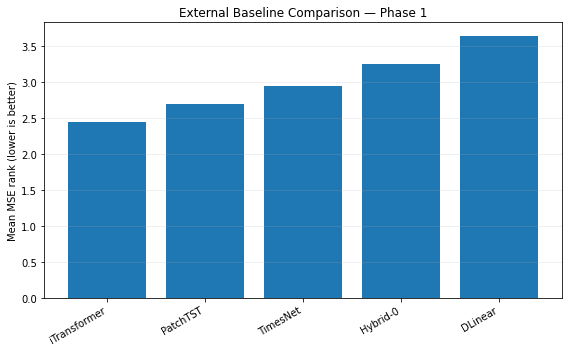

In [37]:

plot_rank = (
    rank_summary
    .sort_values(
        "mean_mse_rank"
    )
)

plt.figure(
    figsize=(
        8,
        5
    )
)

plt.bar(
    plot_rank[
        "model"
    ],
    plot_rank[
        "mean_mse_rank"
    ],
)

plt.ylabel(
    "Mean MSE rank (lower is better)"
)

plt.title(
    "External Baseline Comparison — Phase 1"
)

plt.xticks(
    rotation=30,
    ha="right",
)

plt.grid(
    axis="y",
    alpha=0.25,
)

plt.tight_layout()

plt.show()


# 27. Interpretation

This section configures and evaluates the neural forecasting backbones used by the downstream transfer and intervention experiments.
